In [1]:
import numpy as np
import matplotlib.pyplot as plt
from magnonics import *
from configs_slab.triangular_slabs import *

In [2]:
hamil, lat, basis = Initialize.from_csv('configs/triangular.csv')

hamil.HP_trafo(symbolic=True)

hamil.parameterize_hamil()

Automatically finding sufficient chemical potential...
Using 1e-10 as chemical potential.


1e-10

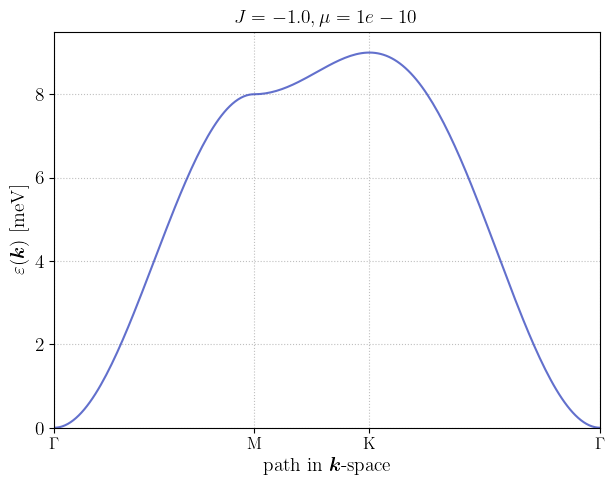

In [3]:
bz = Hexagonal(hamil, 'triangular')
hsp = bz.hsp
disp = bz.get_dispersion(hsp.g, hsp.m, hsp.k, hsp.g, num = 200)
fig = bz.plot_bandstructure(disp, show_params=True)
bz.save_plot(fig, overwrite=True)

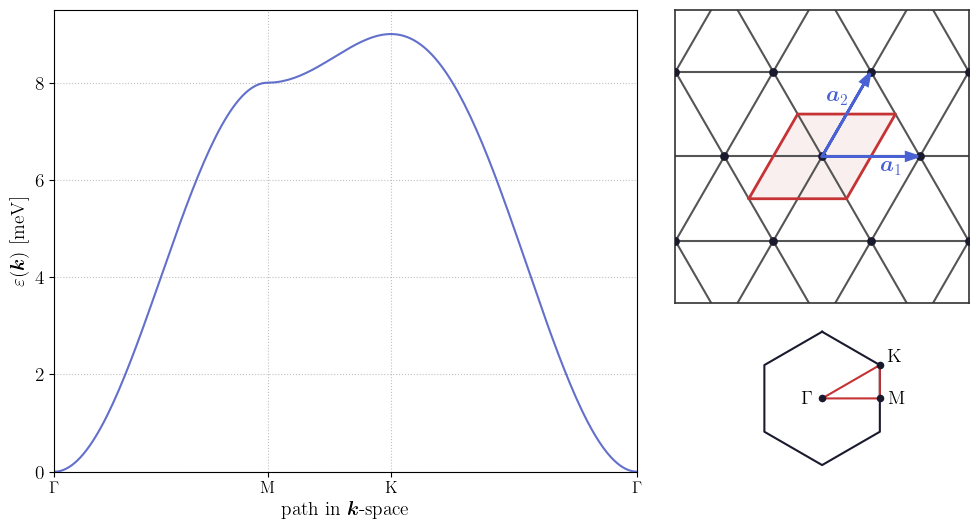

In [5]:
from numpy import sqrt

a = 1

a1 = (a, 0)
a2 = (a/2, sqrt(3) * a / 2)

base_pos = [
    (0.0, 0.0),
]

both = bz.plot_bs_and_lat(disp, 
                          a1, a2, base_pos, 
                          BZ_type='hexagonal',
                        #   cell_origin=(-1/2, -1/2),
                          n_shells=4,
                          view_size=1.5,
                          vect_label_offset_a1 = (-0.3, -0.1),
                          vect_label_offset_a2 = (-0.35, -0.25),
                          figsize = (12,6),
                          wratio = [1.8, 1],
                          hratio = [2, 1],
                          wspace = 0.05,
                          hspace = 0.1,)

bz.save_plot(both, overwrite=True, filename='triangular_BS_combined')

In [2]:
width = 90
flat_hook = build_flat_flat(width)

Setup file saved to: c:\Users\Pascal\Desktop\magnon_code\archimedean\configs_slab\triangular_flat_flat.csv


In [3]:
flat_flat, _, _ = Initialize.from_csv('configs_slab/triangular_flat_flat.csv')

flat_flat.HP_trafo(symbolic=True) ;

flat_flat.parameterize_hamil()

Automatically finding sufficient chemical potential...
Using 0 as chemical potential.


0

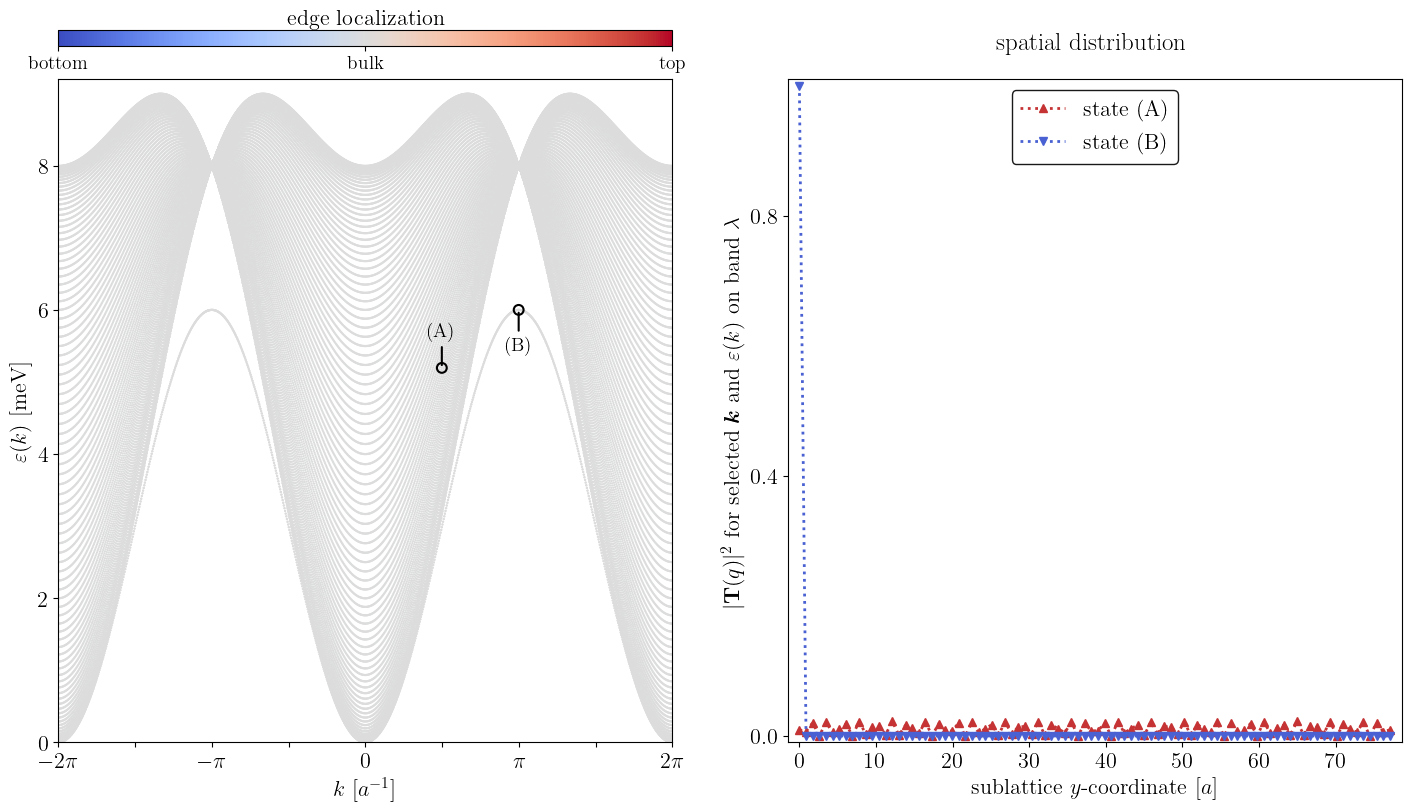

In [4]:
slab = Slab(flat_flat, 'triangular')

state_A = [0.25, 5.2, '(A)', 10, 90]
state_B = [0.5, 3, '(B)', 10, -90]

fig_bs = slab.slab_bandplot(n_unitcells = width, k_space = 'full', states = [state_A, state_B], edge_layers=20)

slab.save_plot(fig_bs, filename = 'triangular_flat_flat_bs', format= '.png', overwrite = True)

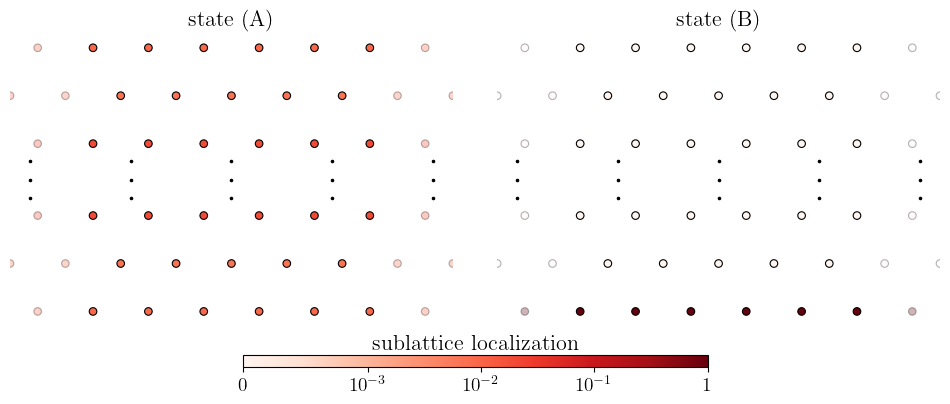

In [6]:
fig_lat = slab.slab_latticeplot(n_unitcells = width, states = [state_A, state_B], reps = 10, gap_dot_scale = (10, 0.8), edge_layers = 3)

slab.save_plot(fig_lat, filename = 'triangular_flat_flat_lat', format= '.png', overwrite = True)